In [ ]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [ ]:
import numpy as np

df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty","age_band_of_casualty","collision_index"], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

# Identifikasi nilai absurd
mask_invalid = df['pedestrian_location'] > 100

# Ganti nilai absurd dengan 0 atau NaN jika tidak bisa dipercaya
df.loc[mask_invalid, 'pedestrian_location'] = 0

# Set pedestrian_location = 0 bila pedestrian_movement == 0
df.loc[df['pedestrian_movement'] == 0, 'pedestrian_location'] = 0

# Gabungkan sebagai string lalu encode dan drop kolom aslinya
df['pedestrian_context'] = df['pedestrian_location'].astype(str) + "_" + df['pedestrian_movement'].astype(str)
df.drop(columns=['pedestrian_location', 'pedestrian_movement'], inplace=True)

# Ganti nilai tidak valid dengan NaN
df['casualty_home_area_type'].replace([-10, 10, 20, 30], np.nan, inplace=True)
df['casualty_imd_decile'].replace(-1, np.nan, inplace=True)

# Imputasi NaN dengan modus
home_mode = df['casualty_home_area_type'].mode()[0]
imd_mode = df['casualty_imd_decile'].mode()[0]

df['casualty_home_area_type'].fillna(home_mode, inplace=True)
df['casualty_imd_decile'].fillna(imd_mode, inplace=True)


missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

Series([], dtype: int64)


/tmp/ipython-input-5-1959781218.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
/tmp/ipython-input-5-1959781218.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
car_passenger,0
bus_or_coach_passenger,0
pedestrian_road_maintenance_worker,0
casualty_type,0
casualty_home_area_type,0


In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['casualty_severity'])
y = df['casualty_severity'] - 1  # ubah label dari [1,2,3] jadi [0,1,2]

categorical_features = [
    'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty',
    'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker',
    'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'pedestrian_context'
]
numerical_features = ['age_of_casualty']

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Encode
ord_enc = OrdinalEncoder()
X[categorical_features] = ord_enc.fit_transform(X[categorical_features])

# Scale
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=["casualty_severity"])
y = df["casualty_severity"] - 1  # klasifikasi 0, 1, 2

label_encoders = {}
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("ExtraTrees", ExtraTreesClassifier(random_state=42)),
    ("Bagging", BaggingClassifier(random_state=42)),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("GradientBoost", GradientBoostingClassifier(random_state=42)),
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=42)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis())
]

# Tambahkan Voting Classifier
voting = VotingClassifier(estimators=[
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
], voting="soft")
models.append(("Voting", voting))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models:
    try:
        scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=cv, n_jobs=-1)
        results.append((name, scores.mean(), scores.std()))
    except Exception as e:
        print(f"{name} error: {e}")

results_df = pd.DataFrame(results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
results_df = results_df.sort_values(by="CrossValMeans", ascending=False).reset_index(drop=True)

print("Fitur yang digunakan:")
print(X.columns.tolist())
print(results_df)


Fitur yang digunakan:
['vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'enhanced_casualty_severity', 'pedestrian_context']
             Algorithm  CrossValMeans  CrossValStd
0        GradientBoost       0.966693     0.000865
1               Voting       0.966532     0.000739
2    HistGradientBoost       0.966505     0.001107
3              XGBoost       0.965755     0.001049
4        Random Forest       0.960342     0.001219
5             AdaBoost       0.956376     0.000952
6              Bagging       0.954018     0.001248
7           ExtraTrees       0.953429     0.001458
8                  KNN       0.937753     0.001399
9        Decision Tree       0.934725     0.002031
10  LogisticRegression       0.927758     0.001129
11                 LDA       0.924971     0.001395
12             

In [ ]:
!pip install optuna --quiet

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === GradientBoost ===
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=30)

# === HistGradientBoost ===
def objective_hgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_iter': trial.suggest_int('max_iter', 100, 300),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 10.0)
    }
    model = HistGradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

study_hgb = optuna.create_study(direction='maximize')
study_hgb.optimize(objective_hgb, n_trials=30)

# === VotingClassifier (soft) ===
def objective_vote(trial):
    voting_type = trial.suggest_categorical("voting", ["soft", "hard"])
    model = VotingClassifier(estimators=[
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ], voting=voting_type)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

study_vote = optuna.create_study(direction='maximize')
study_vote.optimize(objective_vote, n_trials=10)

# === Print Best Results ===
print("=== Best GradientBoost Parameters ===")
print(study_gb.best_params)
print("Best Accuracy:", study_gb.best_value)

print("\n=== Best HistGradientBoost Parameters ===")
print(study_hgb.best_params)
print("Best Accuracy:", study_hgb.best_value)

print("\n=== Best Voting Parameters ===")
print(study_vote.best_params)
print("Best Accuracy:", study_vote.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 14.9 MB/s eta 0:00:00


[I 2025-06-25 14:47:55,100] A new study created in memory with name: no-name-133a38d5-9560-4048-9ec4-1190b5fe16ca
[I 2025-06-25 14:50:32,893] Trial 0 finished with value: 0.9645221355686984 and parameters: {'n_estimators': 175, 'learning_rate': 0.0740237461852216, 'max_depth': 9, 'subsample': 0.6204623553830609, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9645221355686984.
[I 2025-06-25 14:56:58,365] Trial 1 finished with value: 0.9620837000944567 and parameters: {'n_estimators': 278, 'learning_rate': 0.07325387858687057, 'max_depth': 10, 'subsample': 0.6602932909181339, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9645221355686984.
[I 2025-06-25 14:59:09,875] Trial 2 finished with value: 0.9664246366390017 and parameters: {'n_estimators': 192, 'learning_rate': 0.0339003846021397, 'max_depth': 8, 'subsample': 0.9253087064154457, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9664246366390017.
[I 2025-06-25 15:01:26,171] Trial 3 finished with value: 0.964897

=== Best GradientBoost Parameters ===
{'n_estimators': 193, 'learning_rate': 0.057778595810626554, 'max_depth': 4, 'subsample': 0.8193063229446604, 'max_features': 'log2'}
Best Accuracy: 0.9667729861026437

=== Best HistGradientBoost Parameters ===
{'learning_rate': 0.16026402602194084, 'max_iter': 154, 'max_leaf_nodes': 25, 'min_samples_leaf': 47, 'l2_regularization': 6.209523283361477}
Best Accuracy: 0.9670409568950301

=== Best Voting Parameters ===
{'voting': 'soft'}
Best Accuracy: 0.9665318285463738


=== GradientBoost ===
Accuracy: 0.9660235798499464
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       129
           1       0.98      0.67      0.80       836
           2       0.96      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.98      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330



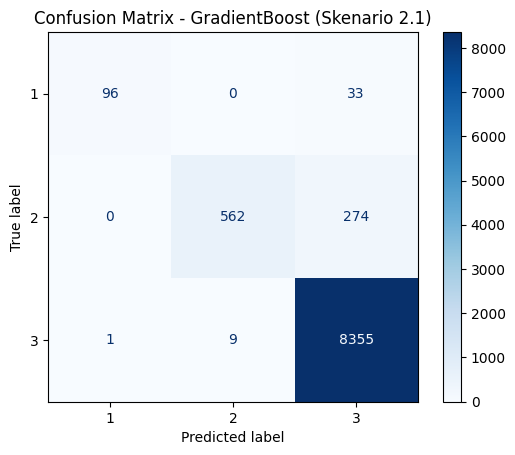


=== HistGradientBoost ===
Accuracy: 0.9659163987138264
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       129
           1       0.98      0.67      0.80       836
           2       0.96      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.98      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330



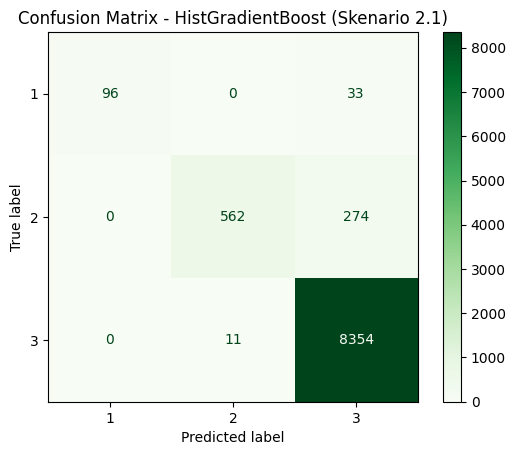

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:49:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== VotingClassifier ===
Accuracy: 0.9664523043944265
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       129
           1       0.99      0.67      0.80       836
           2       0.96      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.99      0.80      0.88      9330
weighted avg       0.97      0.97      0.96      9330



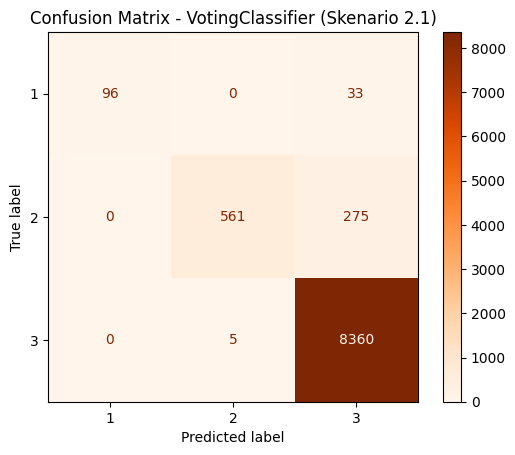

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# === GradientBoost ===
gb_best = GradientBoostingClassifier(
    n_estimators=193,
    learning_rate=0.057778595810626554,
    max_depth=4,
    subsample=0.8193063229446604,
    max_features='log2',
    random_state=42
)
gb_best.fit(X_train, y_train)
y_pred_gb = gb_best.predict(X_test)
print("=== GradientBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(cm_gb, display_labels=[1, 2, 3]).plot(cmap='Blues')
plt.title("Confusion Matrix - GradientBoost (Skenario 2.1)")
plt.show()

# === HistGradientBoost ===
hgb_best = HistGradientBoostingClassifier(
    learning_rate=0.16026402602194084,
    max_iter=154,
    max_leaf_nodes=25,
    min_samples_leaf=47,
    l2_regularization=6.209523283361477,
    random_state=42
)
hgb_best.fit(X_train, y_train)
y_pred_hgb = hgb_best.predict(X_test)
print("\n=== HistGradientBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_hgb))
print(classification_report(y_test, y_pred_hgb))

# Confusion Matrix
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
ConfusionMatrixDisplay(cm_hgb, display_labels=[1, 2, 3]).plot(cmap='Greens')
plt.title("Confusion Matrix - HistGradientBoost (Skenario 2.1)")
plt.show()

# === VotingClassifier ===
voting_best = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
], voting='soft')
voting_best.fit(X_train, y_train)
y_pred_vote = voting_best.predict(X_test)
print("\n=== VotingClassifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))

# Confusion Matrix
cm_vote = confusion_matrix(y_test, y_pred_vote)
ConfusionMatrixDisplay(cm_vote, display_labels=[1, 2, 3]).plot(cmap='Oranges')
plt.title("Confusion Matrix - VotingClassifier (Skenario 2.1)")
plt.show()
